In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# Random Surivial Forests

- an ensemble of survival trees
- survival = survival event + time object
- uses the log-rank test for feature & threshold selection

## Preparing Data for Fitting

In [24]:
# load pre-processed datasets
train_data    = pd.read_csv("../datasets/csv_files/ml_datasets/train_data.csv")
test_data_one   = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_one.csv")
test_data_two   = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_two.csv")
test_data_three = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_three.csv")

In [25]:
# define X & y for all datasets
X_train = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y_train = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

X_test_one = test_data_one.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_one = X_test_one[X_train.columns]
y_test_one = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_one)

X_test_two = test_data_two.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_two = X_test_two[X_train.columns]
y_test_two = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_two)

X_test_three = test_data_three.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_three = X_test_three[X_train.columns]
y_test_three = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_three)

In [26]:
model_path = "../models/rsf_v2.joblib"
random_state = 20

if os.path.exists(model_path):
    print("Loading saved RSF model...")
    rsf = joblib.load(model_path)
    print("Loaded.")
else:
    print("Training RSF (this may take a few minutes)...")
    rsf = RandomSurvivalForest(
        n_estimators=1000,
        min_samples_split=40,   # was 20 — fewer, coarser splits
        min_samples_leaf=50,    # was 30 — larger leaves, less overfit
        max_features="log2",    # was "sqrt" — fewer features per split
        max_depth=10,           # new — cap tree depth
        oob_score=True,
        n_jobs=-1,
        random_state=random_state
    )
    rsf.fit(X_train, y_train)
    joblib.dump(rsf, model_path)
    print("Trained and saved.")

Loading saved RSF model...
Loaded.


## Testing

In [27]:
c_index_train = rsf.score(X_train, y_train)
c_index_test_one = rsf.score(X_test_one, y_test_one)
c_index_test_two = rsf.score(X_test_two, y_test_two)
c_index_test_three = rsf.score(X_test_three, y_test_three)

print(f"Train C-index: {c_index_train:.5f}")
print(f"Test 1 C-index: {c_index_test_one:.5f}")
print(f"Test 2 C-index: {c_index_test_two:.5f}")
print(f"Test 3 C-index: {c_index_test_three:.5f}")
print(f"OOB C-index: {rsf.oob_score_:.5f}")

Train C-index: 0.50000
Test 1 C-index: 0.50000
Test 2 C-index: 0.50000
Test 3 C-index: 0.50000
OOB C-index: 0.07478


## Save Model

In [28]:
os.makedirs("../models", exist_ok=True)
joblib.dump(rsf, "../models/rsf_v2.joblib")

['../models/rsf_v2.joblib']

## Permutation Importance

In [29]:
from sklearn.inspection import permutation_importance

perm_path = "../models/rsf_perm_importance_v2.csv"

if os.path.exists(perm_path):
    print("Loading cached permutation importance...")
    perm_df = pd.read_csv(perm_path)
else:
    print("Computing permutation importance (n_repeats=5, parallelised — may take several minutes)...")
    result = permutation_importance(
        rsf, X_train, y_train,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "gene":             X_train.columns,
        "importance_mean":  result.importances_mean,
        "importance_std":   result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    perm_df.to_csv(perm_path, index=False)
    print("Done. Cached to rsf_perm_importance_v2.csv")

print(f"\nTop 20 features by permutation importance:")
print(perm_df.head(20).to_string(index=False))

Loading cached permutation importance...

Top 20 features by permutation importance:
   gene  importance_mean  importance_std
   ACO1              0.0             0.0
   ADAR              0.0             0.0
 ADIPOQ              0.0             0.0
 AGPAT2              0.0             0.0
  ALDOC              0.0             0.0
    ANG              0.0             0.0
 ANGPT1              0.0             0.0
  ANXA1              0.0             0.0
  AP1M2              0.0             0.0
   APOB              0.0             0.0
   APOD              0.0             0.0
   ARF1              0.0             0.0
ATP6V0B              0.0             0.0
 ATP8B4              0.0             0.0
  BANK1              0.0             0.0
  BIRC5              0.0             0.0
   BLNK              0.0             0.0
   BST1              0.0             0.0
   BST2              0.0             0.0
  BTBD6              0.0             0.0


Saved: rsf_permutation_importance.png


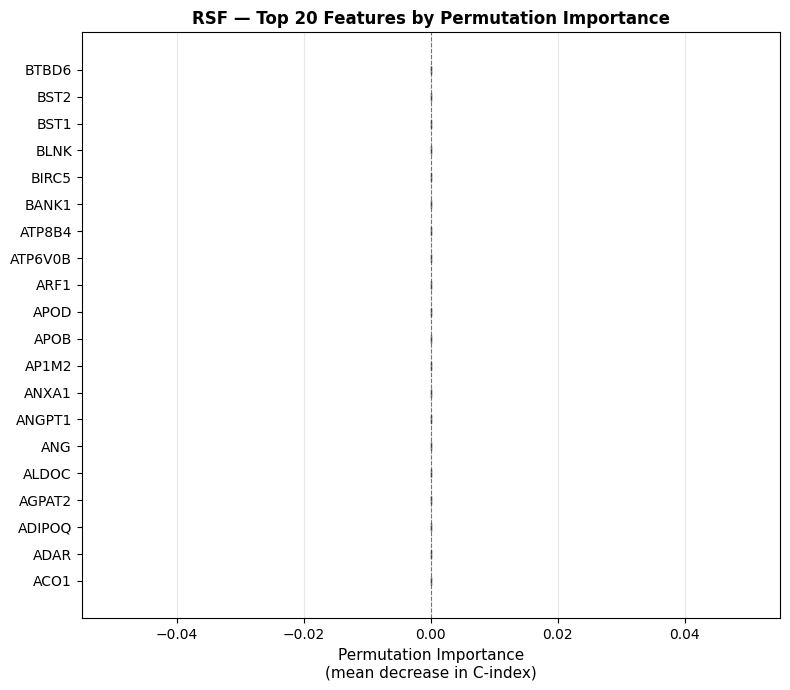

In [30]:
# Bar chart: top 20 genes by permutation importance
top20 = perm_df.head(20).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(top20["gene"], top20["importance_mean"],
               xerr=top20["importance_std"], color="#4DBBD5",
               error_kw=dict(ecolor="grey", capsize=3), edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Permutation Importance\n(mean decrease in C-index)", fontsize=11)
ax.set_title("RSF — Top 20 Features by Permutation Importance", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/rsf_permutation_importance.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_permutation_importance.png")
plt.show()

## RSF Gene Signature

In [31]:
from scipy.stats import spearmanr

# Select signature: top 8 genes with positive importance (aggressive / compact)
sig_df = perm_df[perm_df["importance_mean"] > 0].head(8).copy()
if len(sig_df) < 3:                          # fallback if few positive-importance genes
    sig_df = perm_df.head(8).copy()

sig_genes = sig_df["gene"].tolist()

# Determine direction: Spearman correlation of expression with RSF risk score
rsf_risk_train = rsf.predict(X_train)        # cumulative hazard — higher = higher risk

directions = []
for gene in sig_genes:
    r, p = spearmanr(X_train[gene], rsf_risk_train)
    directions.append({
        "gene":       gene,
        "importance": round(sig_df.loc[sig_df["gene"] == gene, "importance_mean"].values[0], 5),
        "spearman_r": round(r, 4),
        "p_value":    round(p, 4),
        "role":       "danger" if r > 0 else "protective",
    })

sig_genes_df = pd.DataFrame(directions)

# Paper comparison
PAPER_SIGNATURE = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]
in_paper  = [g for g in sig_genes if g in PAPER_SIGNATURE]
not_paper = [g for g in sig_genes if g not in PAPER_SIGNATURE]
missing   = [g for g in PAPER_SIGNATURE if g not in sig_genes]

print("=" * 55)
print(f"  RSF IMMUNE RISK SIGNATURE  ({len(sig_genes)} genes)")
print("=" * 55)
for _, row in sig_genes_df.iterrows():
    marker = "  [paper]" if row["gene"] in PAPER_SIGNATURE else ""
    print(f"  {row['gene']:<12}  imp={row['importance']:.5f}  r={row['spearman_r']:+.3f}  {row['role']}{marker}")

print()
print(f"Paper overlap : {len(in_paper)}/{len(PAPER_SIGNATURE)} — {in_paper}")
print(f"Novel genes   : {not_paper}")
print(f"Paper genes missing: {missing}")

  RSF IMMUNE RISK SIGNATURE  (8 genes)
  ACO1          imp=0.00000  r=+nan  protective  [paper]
  ADAR          imp=0.00000  r=+nan  protective
  ADIPOQ        imp=0.00000  r=+nan  protective
  AGPAT2        imp=0.00000  r=+nan  protective
  ALDOC         imp=0.00000  r=+nan  protective
  ANG           imp=0.00000  r=+nan  protective
  ANGPT1        imp=0.00000  r=+nan  protective
  ANXA1         imp=0.00000  r=+nan  protective

Paper overlap : 1/8 — ['ACO1']
Novel genes   : ['ADAR', 'ADIPOQ', 'AGPAT2', 'ALDOC', 'ANG', 'ANGPT1', 'ANXA1']
Paper genes missing: ['TSLP', 'BIRC5', 'S100B', 'MDK', 'S100P', 'RARRES3', 'BLNK']


C:\Users\ramya\AppData\Local\Temp\ipykernel_22220\2068763720.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_train[gene], rsf_risk_train)


## Risk Score & Patient Stratification

In [32]:
# RSF risk score = predicted cumulative hazard (higher = higher relapse risk)
rsf_risk_test_one   = rsf.predict(X_test_one)
rsf_risk_test_two   = rsf.predict(X_test_two)
rsf_risk_test_three = rsf.predict(X_test_three)

print("Risk score summaries (RSF cumulative hazard):")
for name, scores in [("Train",  rsf_risk_train),
                     ("Test 1", rsf_risk_test_one),
                     ("Test 2", rsf_risk_test_two),
                     ("Test 3", rsf_risk_test_three)]:
    print(f"  {name:8s} — n={len(scores):3d}  mean={scores.mean():.3f}  "
          f"median={np.median(scores):.3f}  min={scores.min():.3f}  max={scores.max():.3f}")

Risk score summaries (RSF cumulative hazard):
  Train    — n=104  mean=13.087  median=13.087  min=13.087  max=13.087
  Test 1   — n=244  mean=13.087  median=13.087  min=13.087  max=13.087
  Test 2   — n= 88  mean=13.087  median=13.087  min=13.087  max=13.087
  Test 3   — n=117  mean=13.087  median=13.087  min=13.087  max=13.087


Training median risk score (cutoff): 13.0871
Train    — high=104  low=  0  log-rank p=nan
Test 1   — high=244  low=  0  log-rank p=nan
Test 2   — high= 88  low=  0  log-rank p=nan
Test 3   — high=117  low=  0  log-rank p=nan

Saved: rsf_km_stratification.png


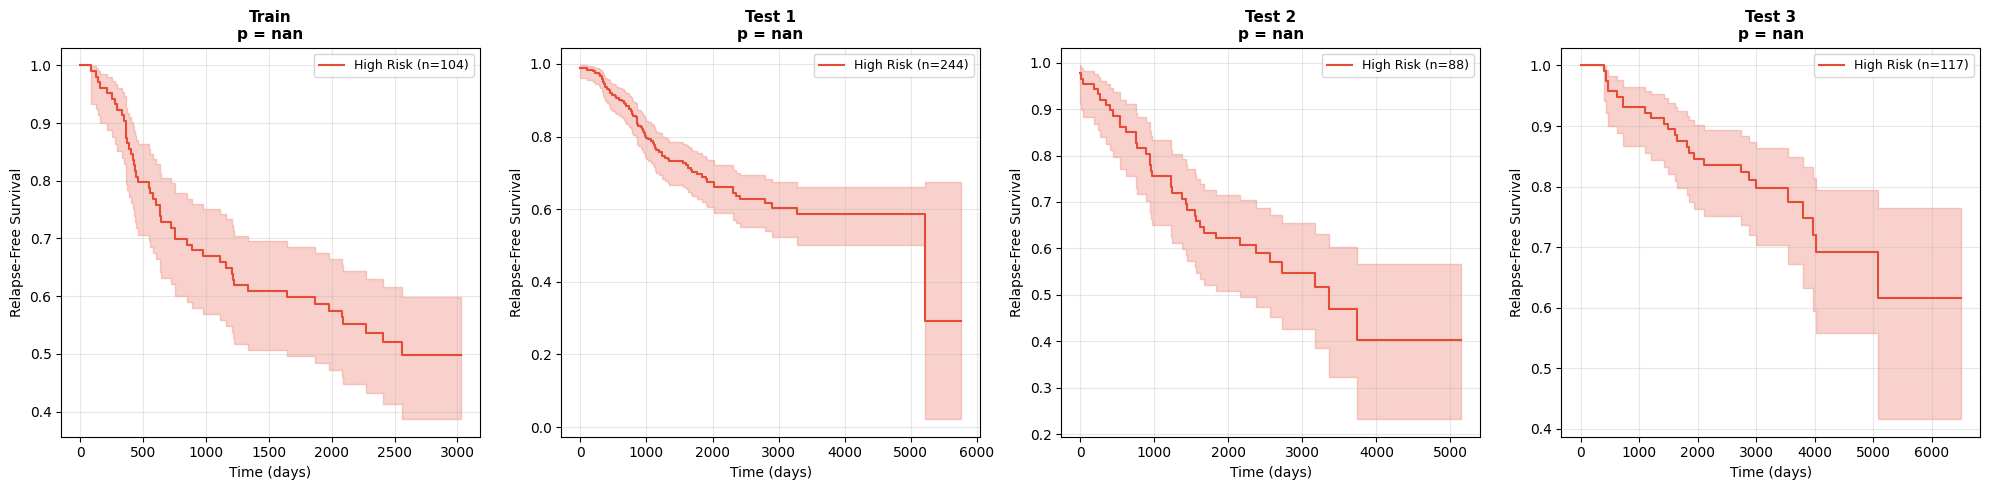

In [33]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Cutoff: median of training risk scores
train_median = np.median(rsf_risk_train)
print(f"Training median risk score (cutoff): {train_median:.4f}")

def stratify(scores):
    return np.where(scores >= train_median, "High Risk", "Low Risk")

def plot_km(df, scores, title, ax):
    groups = stratify(scores)
    tmp = pd.DataFrame({
        "time":  pd.to_numeric(df["relapse_free_time"],  errors="coerce").astype(float),
        "event": pd.to_numeric(df["relapse_free_event"], errors="coerce").astype(bool),
        "group": groups,
    }).dropna(subset=["time", "event"])

    kmf = KaplanMeierFitter()
    colors = {"High Risk": "#E64B35", "Low Risk": "#4DBBD5"}
    for group, color in colors.items():
        mask = tmp["group"] == group
        if mask.sum() == 0:
            continue
        kmf.fit(tmp.loc[mask, "time"], tmp.loc[mask, "event"],
                label=f"{group} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    high = tmp["group"] == "High Risk"
    low  = tmp["group"] == "Low Risk"
    p = logrank_test(tmp.loc[high, "time"], tmp.loc[low, "time"],
                     tmp.loc[high, "event"], tmp.loc[low, "event"]).p_value

    ax.set_title(f"{title}\np = {p:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Relapse-Free Survival")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return p


datasets = [
    ("Train",  train_data,     rsf_risk_train),
    ("Test 1", test_data_one,  rsf_risk_test_one),
    ("Test 2", test_data_two,  rsf_risk_test_two),
    ("Test 3", test_data_three,rsf_risk_test_three),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, df, scores) in zip(axes, datasets):
    groups = stratify(scores)
    p = plot_km(df, scores, name, ax)
    print(f"{name:8s} — high={np.sum(groups=='High Risk'):3d}  "
          f"low={np.sum(groups=='Low Risk'):3d}  log-rank p={p:.4f}")

plt.tight_layout()
plt.savefig("../visuals/rsf_km_stratification.png", dpi=150, bbox_inches="tight")
print("\nSaved: rsf_km_stratification.png")
plt.show()

## Gene Signature Visualizations

Saved: rsf_gene_signature_heatmap.png


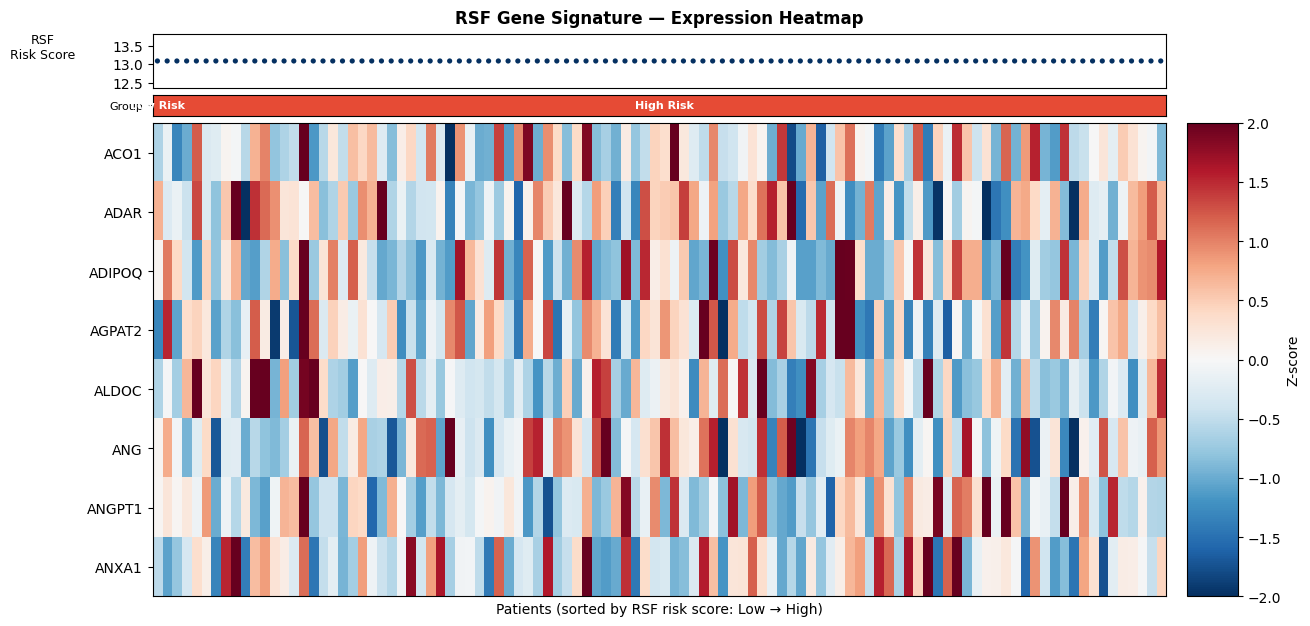

In [34]:
from scipy.stats import zscore
from matplotlib.colors import ListedColormap

# Sort patients by RSF risk score (low → high)
vis_groups       = stratify(rsf_risk_train)
vis_group_series = pd.Series(vis_groups, index=train_data.index)

sort_idx      = np.argsort(rsf_risk_train)
sorted_scores = rsf_risk_train[sort_idx]
sorted_groups = vis_groups[sort_idx]

expr_mat  = train_data[sig_genes].values[sort_idx].T    # (n_genes, n_patients)
expr_z    = zscore(expr_mat, axis=1)
n_patients = expr_mat.shape[1]
split      = int(np.sum(sorted_groups == "Low Risk"))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 2.5 + len(sig_genes) * 0.6))
gs  = fig.add_gridspec(3, 2,
                       height_ratios=[0.9, 0.35, len(sig_genes)],
                       width_ratios=[20, 1],
                       hspace=0.04, wspace=0.04)

ax_rs = fig.add_subplot(gs[0, 0])
ax_rs.scatter(range(n_patients), sorted_scores,
              c=sorted_scores, cmap="RdBu_r", s=14, linewidths=0)
ax_rs.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_rs.set_ylabel("RSF\nRisk Score", fontsize=9, rotation=0, labelpad=50)
ax_rs.set_xlim(-0.5, n_patients - 0.5)
ax_rs.set_xticks([])
ax_rs.set_title("RSF Gene Signature — Expression Heatmap", fontsize=12, fontweight="bold", pad=8)

ax_grp = fig.add_subplot(gs[1, 0], sharex=ax_rs)
ax_grp.imshow(np.where(sorted_groups == "High Risk", 1, 0).reshape(1, -1),
              aspect="auto", cmap=ListedColormap(["#4DBBD5", "#E64B35"]), vmin=0, vmax=1)
ax_grp.set_yticks([0])
ax_grp.set_yticklabels(["Group"], fontsize=8)
ax_grp.set_xticks([])
ax_grp.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_grp.text(split / 2, 0, "Low Risk",  ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax_grp.text(split + (n_patients - split) / 2, 0, "High Risk", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_rs)
im = ax_hm.imshow(expr_z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(sig_genes)))
ax_hm.set_yticklabels(sig_genes, fontsize=10)
ax_hm.set_xlabel("Patients (sorted by RSF risk score: Low → High)", fontsize=10)
ax_hm.axvline(split - 0.5, color="black", lw=1.2, ls="--")

plt.colorbar(im, cax=fig.add_subplot(gs[2, 1]), label="Z-score")
plt.savefig("../visuals/rsf_gene_signature_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_gene_signature_heatmap.png")
plt.show()

Saved: rsf_gene_signature_expression.png


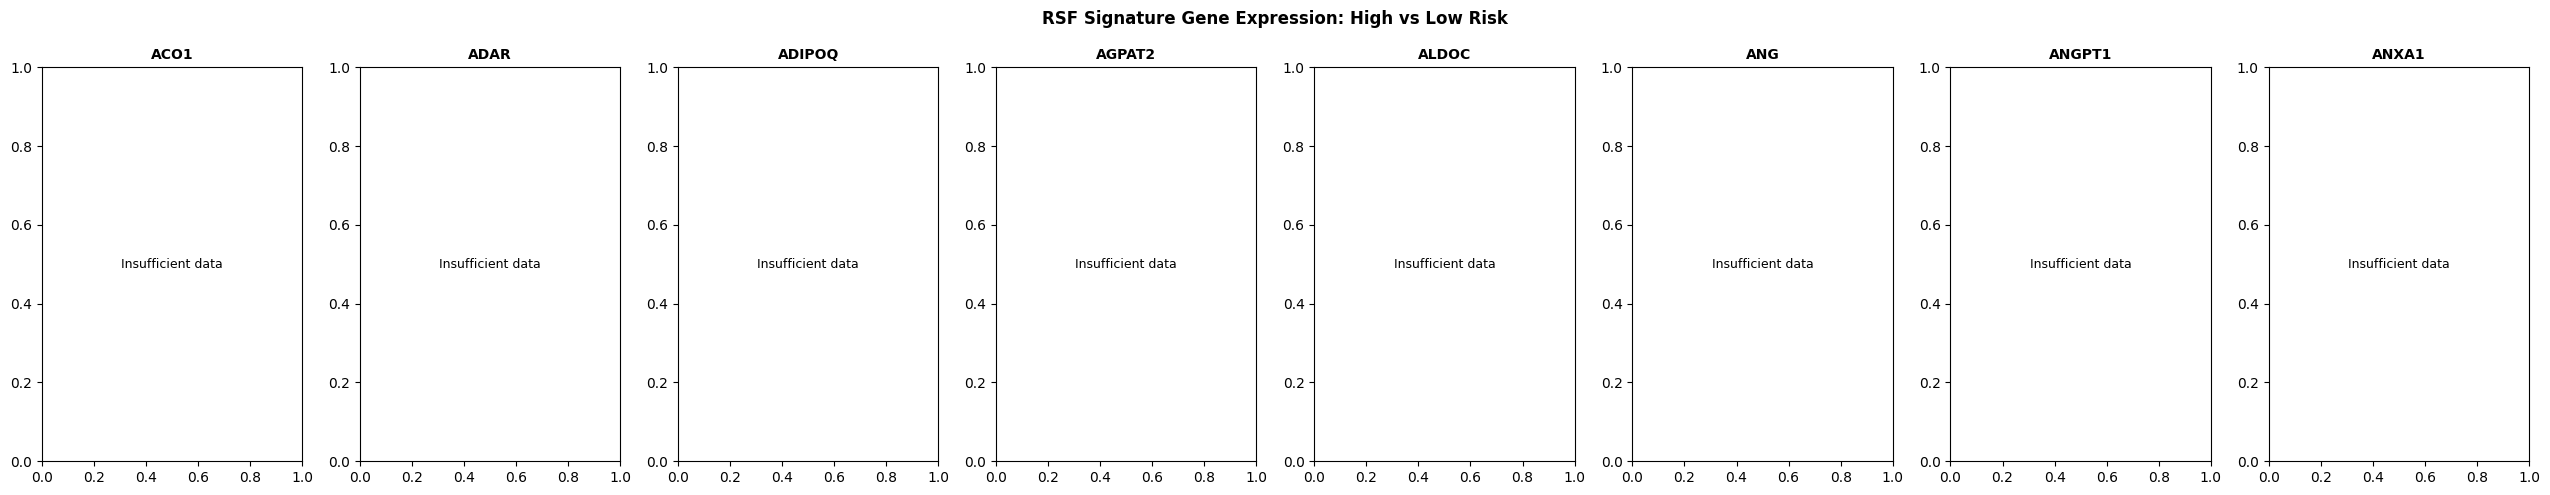

In [35]:
from scipy.stats import mannwhitneyu

# ── Violin plots: sig gene expression in high vs low risk ─────────────────────
# Use numpy boolean masks (vis_groups) to avoid pandas index alignment issues
mask_low  = (vis_groups == "Low Risk")
mask_high = (vis_groups == "High Risk")

n_genes = len(sig_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(max(6, 3.2 * n_genes), 5))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, sig_genes):
    data_low  = train_data[gene].values[mask_low]
    data_high = train_data[gene].values[mask_high]

    if len(data_low) < 2 or len(data_high) < 2:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                transform=ax.transAxes, fontsize=9)
        ax.set_title(gene, fontsize=10, fontweight="bold")
        continue

    parts = ax.violinplot([data_low, data_high], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], ["#4DBBD5", "#E64B35"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    for pos, data, color in [(0, data_low, "#4DBBD5"), (1, data_high, "#E64B35")]:
        jitter = np.random.default_rng(42).normal(0, 0.04, len(data))
        ax.scatter(pos + jitter, data, alpha=0.45, s=16, color=color, zorder=3)

    _, p = mannwhitneyu(data_low, data_high, alternative="two-sided")
    role = sig_genes_df.loc[sig_genes_df["gene"] == gene, "role"].values[0]
    ax.text(0.5, 0.97, f"p = {p:.3f}" + (" *" if p < 0.05 else ""),
            transform=ax.transAxes, ha="center", va="top", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low Risk", "High Risk"], fontsize=9)
    ax.set_title(f"{gene}\n({role})", fontsize=10, fontweight="bold")
    ax.set_ylabel("Expression (log₂)", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("RSF Signature Gene Expression: High vs Low Risk", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/rsf_gene_signature_expression.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_gene_signature_expression.png")
plt.show()

Saved: rsf_gene_signature_correlation.png


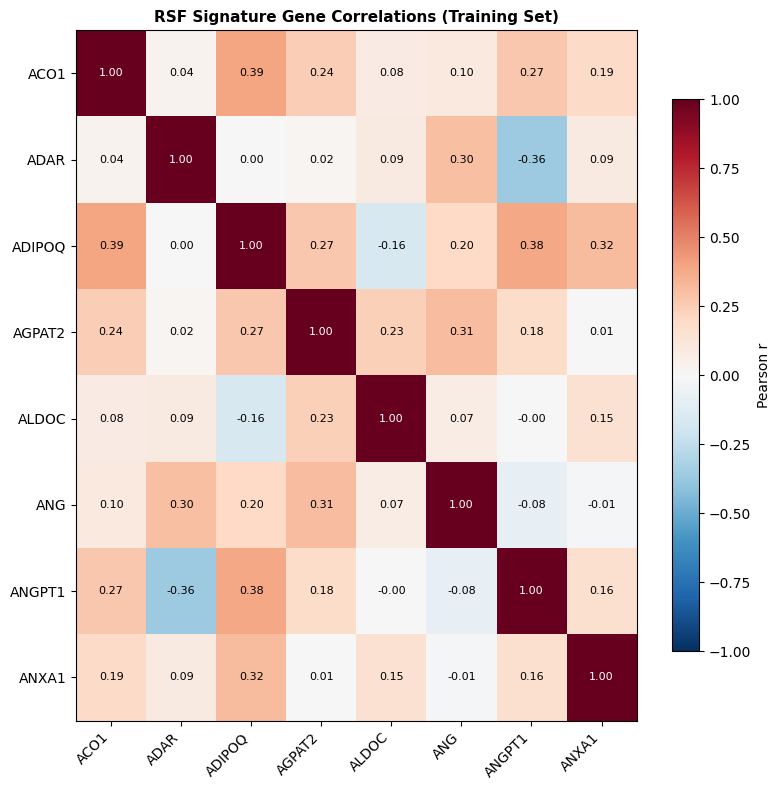

In [36]:
# ── Correlation heatmap between sig genes ─────────────────────────────────────
if len(sig_genes) > 1:
    corr = train_data[sig_genes].corr(method="pearson")

    fig, ax = plt.subplots(figsize=(max(4, len(sig_genes)), max(3.5, len(sig_genes))))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(sig_genes)))
    ax.set_yticks(range(len(sig_genes)))
    ax.set_xticklabels(sig_genes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(sig_genes, fontsize=10)

    for i in range(len(sig_genes)):
        for j in range(len(sig_genes)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.6 else "black")

    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    ax.set_title("RSF Signature Gene Correlations (Training Set)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visuals/rsf_gene_signature_correlation.png", dpi=150, bbox_inches="tight")
    print("Saved: rsf_gene_signature_correlation.png")
    plt.show()
else:
    print("Only 1 significant gene — correlation heatmap skipped.")